<a href="https://colab.research.google.com/github/vragarwal/FDS-Results/blob/main/vradhi%20exp%204%20fds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [10]:
from google.colab import files
uploaded = files.upload()

Saving V_S_DATA SET_CLIMATE (1).csv to V_S_DATA SET_CLIMATE (1).csv


In [11]:
df = pd.read_csv("V_S_DATA SET_CLIMATE (1).csv")
print(df.head())
print(df.columns.tolist())

       country  longitude        timezone      last_updated  \
0  Afghanistan      69.18      Asia/Kabul  16-05-2024 13:15   
1      Albania      19.82   Europe/Tirane  16-05-2024 10:45   
2      Algeria       3.05  Africa/Algiers  16-05-2024 09:45   
3      Andorra       1.52  Europe/Andorra  16-05-2024 10:45   
4       Angola      13.23   Africa/Luanda  16-05-2024 09:45   

   temperature_celsius condition_text  wind_kph  wind_degree wind_direction  \
0                 26.6  Partly Cloudy      13.3          338            NNW   
1                 19.0  Partly cloudy      11.2          320             NW   
2                 23.0          Sunny      15.1          280              W   
3                  6.3  Light drizzle      11.9          215             SW   
4                 26.0  Partly cloudy      13.0          150            SSE   

   precip_mm  humidity  visibility_km  gust_mph  air_quality_Ozone  \
0        0.0        24           10.0       9.5              103.0   
1     

In [12]:
def corr(x, y):
    n = len(x)
    sx = sy = sxy = sx2 = sy2 = 0

    for i in range(n):
        sx += x[i]
        sy += y[i]
        sxy += x[i] * y[i]
        sx2 += x[i] * x[i]
        sy2 += y[i] * y[i]

    a = n * sxy - sx * sy
    b = (n * sx2 - sx * sx) * (n * sy2 - sy * sy)

    if b <= 0:
        return 0

    return a / math.sqrt(b)

In [13]:
pairs = [
    ("temperature_celsius", "air_quality_Ozone"),
    ("temperature_celsius", "humidity"),
    ("wind_kph", "precip_mm")
]

for a, b in pairs:
    data = df[[a, b]].dropna()

    x = data[a].tolist()
    y = data[b].tolist()

    r = corr(x, y)

    print(a, "and", b)
    print("Correlation =", round(r, 3))

    if r > 0:
        print("Positive correlation")
    elif r < 0:
        print("Negative correlation")
    else:
        print("No linear correlation")

    print()

temperature_celsius and air_quality_Ozone
Correlation = 0.254
Positive correlation

temperature_celsius and humidity
Correlation = -0.34
Negative correlation

wind_kph and precip_mm
Correlation = 0.01
Positive correlation



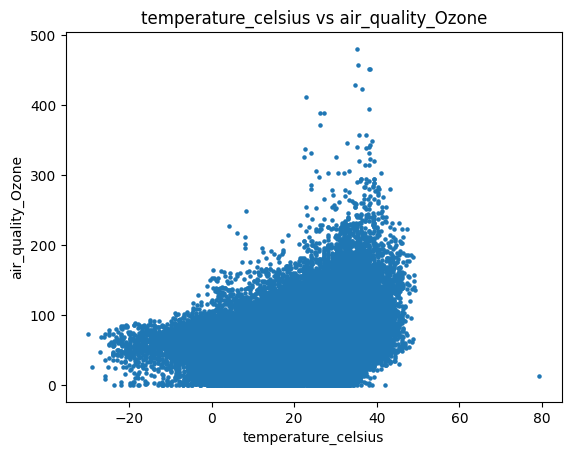

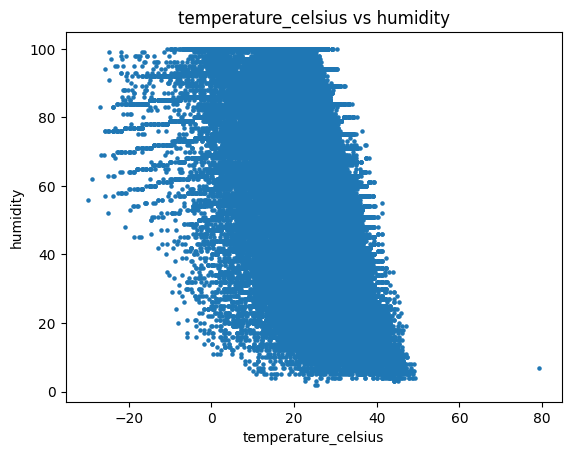

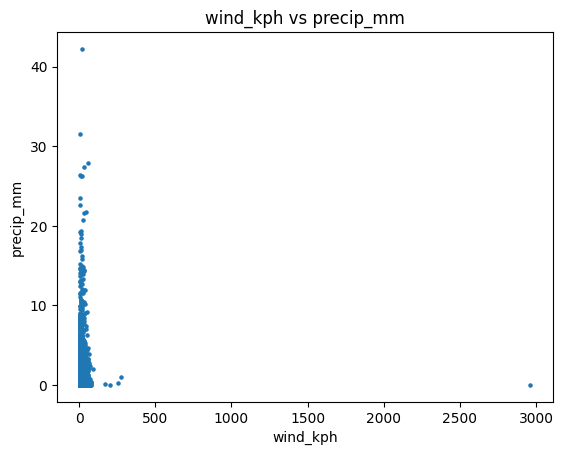

In [14]:
for a, b in pairs:
    data = df[[a, b]].dropna()

    plt.scatter(data[a], data[b], s=5)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.title(a + " vs " + b)
    plt.show()